In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [2]:
aln = ALNModel()

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln = ALNModel()

aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

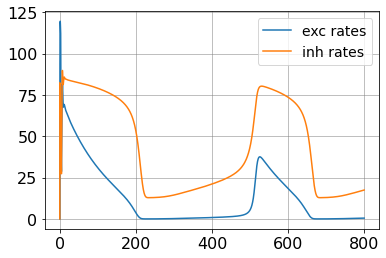

In [4]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

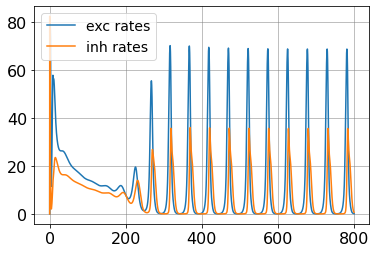

In [5]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

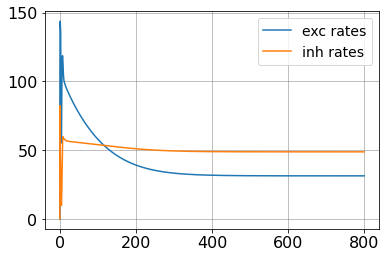

[31.3071 48.7679]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

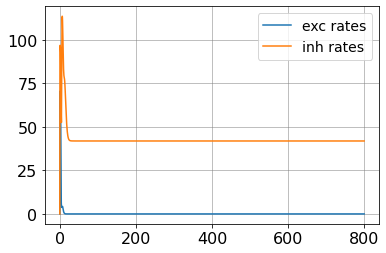

[4.4451e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

### D

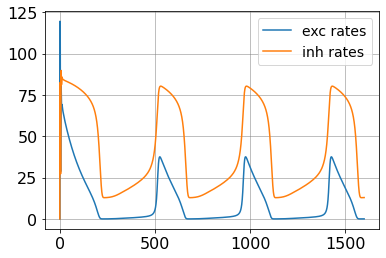

(10.812570519150109, 59.83114811722191, 0.0)


In [10]:
dur = 1000
dur_pre = 400
dur_post = 400
aln.params.duration = dur

set_params_down()

# set fast oscillation as target
aln.params.duration = 1600.
set_params_slow()
control0 = aln.getZeroControl()
target = aln.getZeroTargetOsc()

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

rate_exc = aln.rates_exc[0,:]
rate_inh = aln.rates_inh[0,:]

print(cost.get_osc_params(rate_exc))

tol = 1e-12
start_step = 10.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [9]:
# C.a.1) fast osc => low, max current 1nA, precision only
case = "Ca1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

max_it = 1000

setinit(fast_osc_init)

control0 = aln.getZeroControl()
control0[:,0,:] = - 0.5
control0[:,1,:] = 3.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlCa1[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCa1, bestStateCa1, costCa1, runtimeCa1, gradCa1 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultCa1 = {"Opt_control": bestControlCa1,
              "Opt_state": bestStateCa1,
              "costArray": costCa1,
              "runtimeArray": runtimeCa1,    
}

dump_dicts = [opt_params, aln.params, resultCa1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  11635.81349596806
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  275.24992806102614
too large start step, decrease to  0.078125
RUN  2 , total integrated cost =  136.15426902179138
RUN  3 , total integrated cost =  126.16341304917142
RUN  4 , total integrated cost =  116.97879117869033
RUN  5 , total integrated cost =  110.77160435157516
RUN  6 , total integrated cost =  105.25298318968989
RUN  7 , total integrated cost =  100.54716358776017
RUN  8 , total integrated cost =  95.54200630270641
RUN  9 , total integrated cost =  91.47393103931368
RUN  10 , total integrated cost =  88.3509789214585
RUN  11 , total integrated cost =  85.83967869139823
RUN  12 , total integrated cost =  82.55976177834492
RUN  13 , total integrated cost =  79.60668059273094
RUN  14 , total integrated cost =  77.3896939053416
RUN  15 , total integrated cost =  75.76908939791484
RUN  16 ,

too small start step, increase to  10.0
RUN  115 , total integrated cost =  56.16698144359981
RUN  116 , total integrated cost =  56.160568617376725
RUN  117 , total integrated cost =  56.15715248058677
RUN  118 , total integrated cost =  56.15371404154812
RUN  119 , total integrated cost =  56.150612395612896
RUN  120 , total integrated cost =  56.147194389303834
RUN  121 , total integrated cost =  56.144123876464434
RUN  122 , total integrated cost =  56.140741714321344
RUN  123 , total integrated cost =  56.13778469123212
RUN  124 , total integrated cost =  56.134394767666485
RUN  125 , total integrated cost =  56.13153741845415
RUN  126 , total integrated cost =  56.128035069448714
RUN  127 , total integrated cost =  56.1251419664097
RUN  128 , total integrated cost =  56.1217304337297
RUN  129 , total integrated cost =  56.11843545004157
too large start step, decrease to  0.078125
RUN  130 , total integrated cost =  56.115645166104365
too small start step, increase to  10.0
too sm

RUN  230 , total integrated cost =  55.918649150883134
RUN  231 , total integrated cost =  55.91813643835593
RUN  232 , total integrated cost =  55.91759705708587
RUN  233 , total integrated cost =  55.91705170879941
RUN  234 , total integrated cost =  55.91651650021866
too large start step, decrease to  10.0
RUN  235 , total integrated cost =  55.916027194811676
too small start step, increase to  1280.0
RUN  236 , total integrated cost =  55.915552404932754
too large start step, decrease to  10.0
RUN  237 , total integrated cost =  55.91506446354774
too small start step, increase to  1280.0
RUN  238 , total integrated cost =  55.9145832704476
too large start step, decrease to  10.0
RUN  239 , total integrated cost =  55.914100758431005
too small start step, increase to  1280.0
RUN  240 , total integrated cost =  55.91363474113809
RUN  241 , total integrated cost =  55.9131741416943
RUN  242 , total integrated cost =  55.912726388036454
too large start step, decrease to  10.0
RUN  243 

RUN  373 , total integrated cost =  55.87199078528599
too large start step, decrease to  1280.0
RUN  374 , total integrated cost =  55.87190763659053
too small start step, increase to  163840.0
RUN  375 , total integrated cost =  55.871827340049336
too large start step, decrease to  1280.0
RUN  376 , total integrated cost =  55.87174988941629
too small start step, increase to  163840.0
RUN  377 , total integrated cost =  55.87167293472431
too large start step, decrease to  1280.0
RUN  378 , total integrated cost =  55.8715950951115
too small start step, increase to  163840.0
RUN  379 , total integrated cost =  55.87151533349277
too large start step, decrease to  1280.0
RUN  380 , total integrated cost =  55.871437647876306
too small start step, increase to  163840.0
RUN  381 , total integrated cost =  55.87136081004747
too large start step, decrease to  1280.0
RUN  382 , total integrated cost =  55.87128319279142
too small start step, increase to  163840.0
RUN  383 , total integrated c

RUN  475 , total integrated cost =  55.866061311926586
RUN  476 , total integrated cost =  55.86603153780148
RUN  477 , total integrated cost =  55.86600132537826
RUN  478 , total integrated cost =  55.86597329067986
RUN  479 , total integrated cost =  55.865944888855395
RUN  480 , total integrated cost =  55.865916285245405
RUN  481 , total integrated cost =  55.865887214393574
RUN  482 , total integrated cost =  55.86586028092074
RUN  483 , total integrated cost =  55.865832950908136
RUN  484 , total integrated cost =  55.86580547671273
RUN  485 , total integrated cost =  55.86577749823862
RUN  486 , total integrated cost =  55.86575162633662
RUN  487 , total integrated cost =  55.865725322692036
RUN  488 , total integrated cost =  55.86569893739626
RUN  489 , total integrated cost =  55.86567200510355
RUN  490 , total integrated cost =  55.86564715473249
too large start step, decrease to  1280.0
RUN  491 , total integrated cost =  55.86561783548311
too small start step, increase to 

...

RUN  722 , total integrated cost =  55.8631671081745
RUN  723 , total integrated cost =  55.86316437675594
RUN  724 , total integrated cost =  55.863162293758464
RUN  725 , total integrated cost =  55.86315987463853
RUN  726 , total integrated cost =  55.86315769523243
RUN  727 , total integrated cost =  55.8631555721954
RUN  728 , total integrated cost =  55.863154114838714
RUN  729 , total integrated cost =  55.86315260063241
RUN  730 , total integrated cost =  55.8631510058122
RUN  731 , total integrated cost =  55.863149238193806
RUN  732 , total integrated cost =  55.86314757997996
RUN  733 , total integrated cost =  55.86314561707732
RUN  734 , total integrated cost =  55.86314336158942
RUN  735 , total integrated cost =  55.863141082904285
RUN  736 , total integrated cost =  55.863139217601464
RUN  737 , total integrated cost =  55.86313717245104
RUN  738 , total integrated cost =  55.8631352331009
RUN  739 , total integrated cost =  55.863133061054356
RUN  740 , total integrate

RUN  865 , total integrated cost =  55.86302865323634
RUN  866 , total integrated cost =  55.863028197292984
RUN  867 , total integrated cost =  55.86302771818386
RUN  868 , total integrated cost =  55.86302713128714
RUN  869 , total integrated cost =  55.86302658423836
RUN  870 , total integrated cost =  55.86302610207652
RUN  871 , total integrated cost =  55.86302562675257
RUN  872 , total integrated cost =  55.86302510185982
RUN  873 , total integrated cost =  55.863024553529975
RUN  874 , total integrated cost =  55.863024121051566
RUN  875 , total integrated cost =  55.86302371396171
RUN  876 , total integrated cost =  55.86302336745998
RUN  877 , total integrated cost =  55.86302301248168
RUN  878 , total integrated cost =  55.863022718672546
RUN  879 , total integrated cost =  55.863022426439926
RUN  880 , total integrated cost =  55.86302214433551
too large start step, decrease to  163840.0
RUN  881 , total integrated cost =  55.86302186575611
too small start step, increase to

RUN  960 , total integrated cost =  55.86300493304035
RUN  961 , total integrated cost =  55.86300476597378
too large start step, decrease to  163840.0
RUN  962 , total integrated cost =  55.86300457694061
too small start step, increase to  20971520.0
RUN  963 , total integrated cost =  55.863004418003634
RUN  964 , total integrated cost =  55.86300425510036
too large start step, decrease to  163840.0
RUN  965 , total integrated cost =  55.86300412149773
too small start step, increase to  20971520.0
RUN  966 , total integrated cost =  55.863003985527904
too large start step, decrease to  163840.0
RUN  967 , total integrated cost =  55.86300384571696
too small start step, increase to  20971520.0
RUN  968 , total integrated cost =  55.863003693774445
RUN  969 , total integrated cost =  55.863003554608476
RUN  970 , total integrated cost =  55.86300340689081
RUN  971 , total integrated cost =  55.86300327071903
RUN  972 , total integrated cost =  55.86300313191705
RUN  973 , total integra

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  55.86299966179864
Improved over  1000  iterations by  99.51990464885712  percent.
Problem in initial value trasfer:  Vmean_exc -56.750931763059825 -56.77080766962767
Problem in initial value trasfer:  Vmean_exc -80.81146335298429 -80.81146247790755


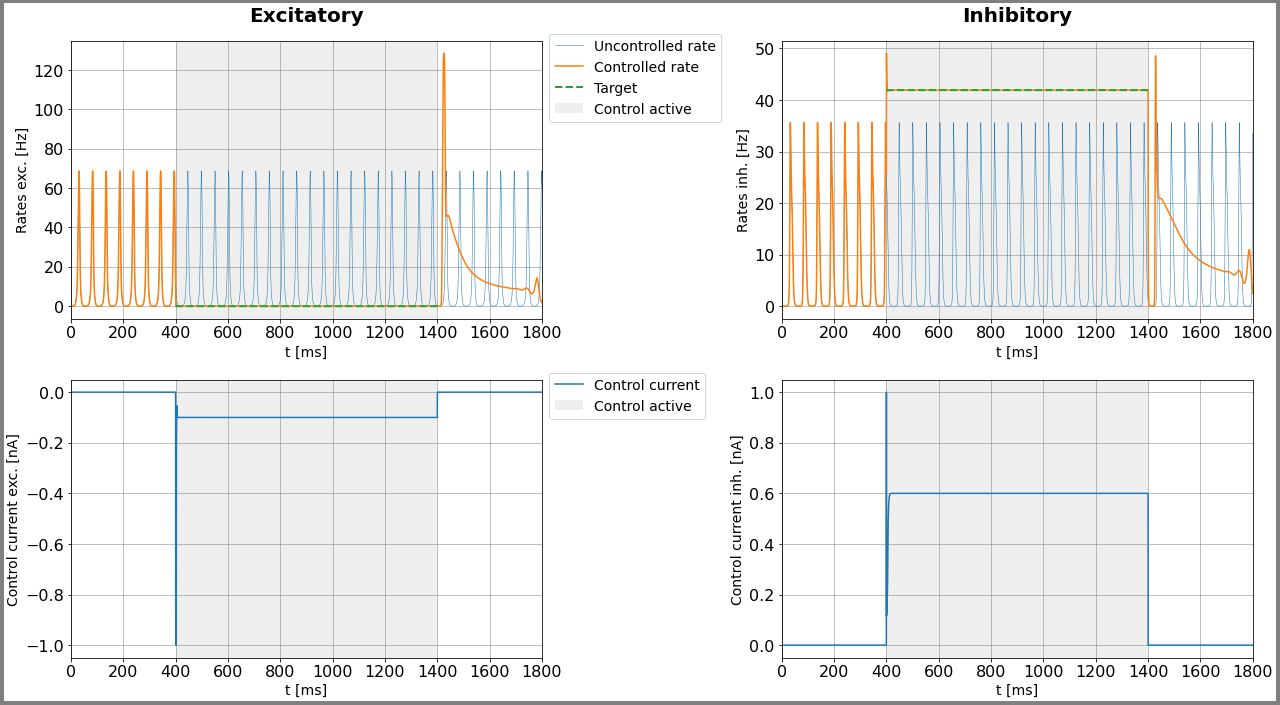

In [10]:
plotFunc.plot_control(aln, bestControlCa1, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

In [11]:
# C.a.2) fast osc => low, max current 1nA, precision + energy + sparsity
case = "Ca2"
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

#max_it = 10

setinit(fast_osc_init)
control0 = aln.getZeroControl()
control0[:,0,:] = - 0.5
control0[:,1,:] = 3.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlEa2[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCa2, bestStateCa2, costCa2, runtimeCa2, gradCa2 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultCa2 = {"Opt_control": bestControlCa2,
              "Opt_state": bestStateCa2,
              "costArray": costCa2,
              "runtimeArray": runtimeCa2,    
}

dump_dicts = [opt_params, aln.params, resultCa2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  16371.961247919764
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  4973.105455524912
too large start step, decrease to  0.078125
RUN  2 , total integrated cost =  4832.177100802719
RUN  3 , total integrated cost =  4821.944870344085
RUN  4 , total integrated cost =  4796.884952203103
RUN  5 , total integrated cost =  4787.19931581388
RUN  6 , total integrated cost =  4761.246237176977
too small start step, increase to  10.0
RUN  7 , total integrated cost =  4701.440760172225
too large start step, decrease to  0.078125
RUN  8 , total integrated cost =  4692.844242427167
too small start step, increase to  10.0
RUN  9 , total integrated cost =  4661.683116812471
too large start step, decrease to  0.078125
RUN  10 , total integrated cost =  4645.096137499845
too small start step, increase to  10.0
RUN  11 , total integrated cost =  4642.668648924578
RUN  12 , total in

too small start step, increase to  0.078125
RUN  130 , total integrated cost =  4627.103206289535
RUN  131 , total integrated cost =  4627.099731903089
RUN  132 , total integrated cost =  4627.096387640195
RUN  133 , total integrated cost =  4627.093511359549
RUN  134 , total integrated cost =  4627.090582766164
too large start step, decrease to  0.0006103515625
RUN  135 , total integrated cost =  4627.087430772799
too small start step, increase to  0.078125
RUN  136 , total integrated cost =  4627.08445607149
RUN  137 , total integrated cost =  4627.081471403572
RUN  138 , total integrated cost =  4627.078446934073
RUN  139 , total integrated cost =  4627.07562033955
RUN  140 , total integrated cost =  4627.072962665701
RUN  141 , total integrated cost =  4627.069848203939
RUN  142 , total integrated cost =  4627.066764385363
RUN  143 , total integrated cost =  4627.064181805512
RUN  144 , total integrated cost =  4627.06148114022
RUN  145 , total integrated cost =  4627.058646872786


too small start step, increase to  0.0006103515625
RUN  254 , total integrated cost =  4626.863822171895
RUN  255 , total integrated cost =  4626.862706592651
too large start step, decrease to  4.76837158203125e-06
RUN  256 , total integrated cost =  4626.861556619829
RUN  257 , total integrated cost =  4626.860328732845
too small start step, increase to  0.0006103515625
RUN  258 , total integrated cost =  4626.859153595602
too large start step, decrease to  4.76837158203125e-06
RUN  259 , total integrated cost =  4626.857986476162
too small start step, increase to  0.0006103515625
RUN  260 , total integrated cost =  4626.856784610985
RUN  261 , total integrated cost =  4626.85567327775
too large start step, decrease to  4.76837158203125e-06
RUN  262 , total integrated cost =  4626.854611889847
RUN  263 , total integrated cost =  4626.853384819659
too small start step, increase to  0.0006103515625
RUN  264 , total integrated cost =  4626.8521453354015
RUN  265 , total integrated cost =

RUN  380 , total integrated cost =  4626.763300322346
RUN  381 , total integrated cost =  4626.762912697177
RUN  382 , total integrated cost =  4626.762527745805
RUN  383 , total integrated cost =  4626.762094034325
RUN  384 , total integrated cost =  4626.761626013919
too large start step, decrease to  0.0006103515625
RUN  385 , total integrated cost =  4626.761065967807
too small start step, increase to  0.078125
RUN  386 , total integrated cost =  4626.7605193407535
too large start step, decrease to  0.0006103515625
RUN  387 , total integrated cost =  4626.760053081964
too small start step, increase to  0.078125
RUN  388 , total integrated cost =  4626.7595709064635
too large start step, decrease to  0.0006103515625
RUN  389 , total integrated cost =  4626.759057918895
too small start step, increase to  0.078125
RUN  390 , total integrated cost =  4626.758564246264
too large start step, decrease to  0.0006103515625
RUN  391 , total integrated cost =  4626.758077000018
too small star

too small start step, increase to  2.2737367544323206e-12
too small start step, increase to  0.078125
RUN  462 , total integrated cost =  4626.73139755934
too large start step, decrease to  0.0006103515625
RUN  463 , total integrated cost =  4626.731086481915
too small start step, increase to  0.078125
RUN  464 , total integrated cost =  4626.730766733972
too large start step, decrease to  0.0006103515625
RUN  465 , total integrated cost =  4626.730470632274
too small start step, increase to  0.078125
RUN  466 , total integrated cost =  4626.730187686903
RUN  467 , total integrated cost =  4626.729861259423
RUN  468 , total integrated cost =  4626.729529920388
too large start step, decrease to  0.0006103515625
RUN  469 , total integrated cost =  4626.729257707716
too small start step, increase to  0.078125
RUN  470 , total integrated cost =  4626.729008036849
too large start step, decrease to  0.0006103515625
RUN  471 , total integrated cost =  4626.728787142881
RUN  472 , total integr

...

RUN  663 , total integrated cost =  4626.694277732197
RUN  664 , total integrated cost =  4626.694201184318
RUN  665 , total integrated cost =  4626.694140402281
too large start step, decrease to  4.76837158203125e-06
RUN  666 , total integrated cost =  4626.694082996119
RUN  667 , total integrated cost =  4626.694003900275
too small start step, increase to  0.0006103515625
RUN  668 , total integrated cost =  4626.69392828484
RUN  669 , total integrated cost =  4626.693869765566
too large start step, decrease to  4.76837158203125e-06
RUN  670 , total integrated cost =  4626.693813188063
RUN  671 , total integrated cost =  4626.693737282638
too small start step, increase to  0.0006103515625
RUN  672 , total integrated cost =  4626.693662578606
too large start step, decrease to  4.76837158203125e-06
RUN  673 , total integrated cost =  4626.693606260193
too large start step, decrease to  3.725290298461914e-08
RUN  674 , total integrated cost =  4626.693550491794
RUN  675 , total integrate

RUN  780 , total integrated cost =  4626.687612300238
RUN  781 , total integrated cost =  4626.687590204639
RUN  782 , total integrated cost =  4626.68756929211
RUN  783 , total integrated cost =  4626.6875406480185
RUN  784 , total integrated cost =  4626.687513018183
RUN  785 , total integrated cost =  4626.687449220759
too small start step, increase to  2.9103830456733704e-10
too small start step, increase to  3.725290298461914e-08
too small start step, increase to  4.76837158203125e-06
too small start step, increase to  0.0006103515625
RUN  786 , total integrated cost =  4626.687384485521
too large start step, decrease to  4.76837158203125e-06
RUN  787 , total integrated cost =  4626.687358119383
RUN  788 , total integrated cost =  4626.687330982151
RUN  789 , total integrated cost =  4626.687272643797
too small start step, increase to  0.0006103515625
RUN  790 , total integrated cost =  4626.687216348398
RUN  791 , total integrated cost =  4626.687189393774
too large start step, d

RUN  914 , total integrated cost =  4626.684841298363
RUN  915 , total integrated cost =  4626.684834291205
RUN  916 , total integrated cost =  4626.684828095389
RUN  917 , total integrated cost =  4626.684821428492
RUN  918 , total integrated cost =  4626.6848150673595
RUN  919 , total integrated cost =  4626.684808738879
RUN  920 , total integrated cost =  4626.684803104397
RUN  921 , total integrated cost =  4626.684796136719
RUN  922 , total integrated cost =  4626.6847895229475
RUN  923 , total integrated cost =  4626.684783703727
RUN  924 , total integrated cost =  4626.684777870622
RUN  925 , total integrated cost =  4626.684771496518
RUN  926 , total integrated cost =  4626.684765508195
RUN  927 , total integrated cost =  4626.684759462791
RUN  928 , total integrated cost =  4626.684754156406
RUN  929 , total integrated cost =  4626.6847474927945
RUN  930 , total integrated cost =  4626.684741268243
RUN  931 , total integrated cost =  4626.684735703486
RUN  932 , total integrat

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  4626.684242179721
Improved over  1000  iterations by  71.74019549571318  percent.
Problem in initial value trasfer:  Vmean_exc -56.750931763059825 -56.77080766962767
Problem in initial value trasfer:  Vmean_exc -76.96806674961185 -76.96806910847869


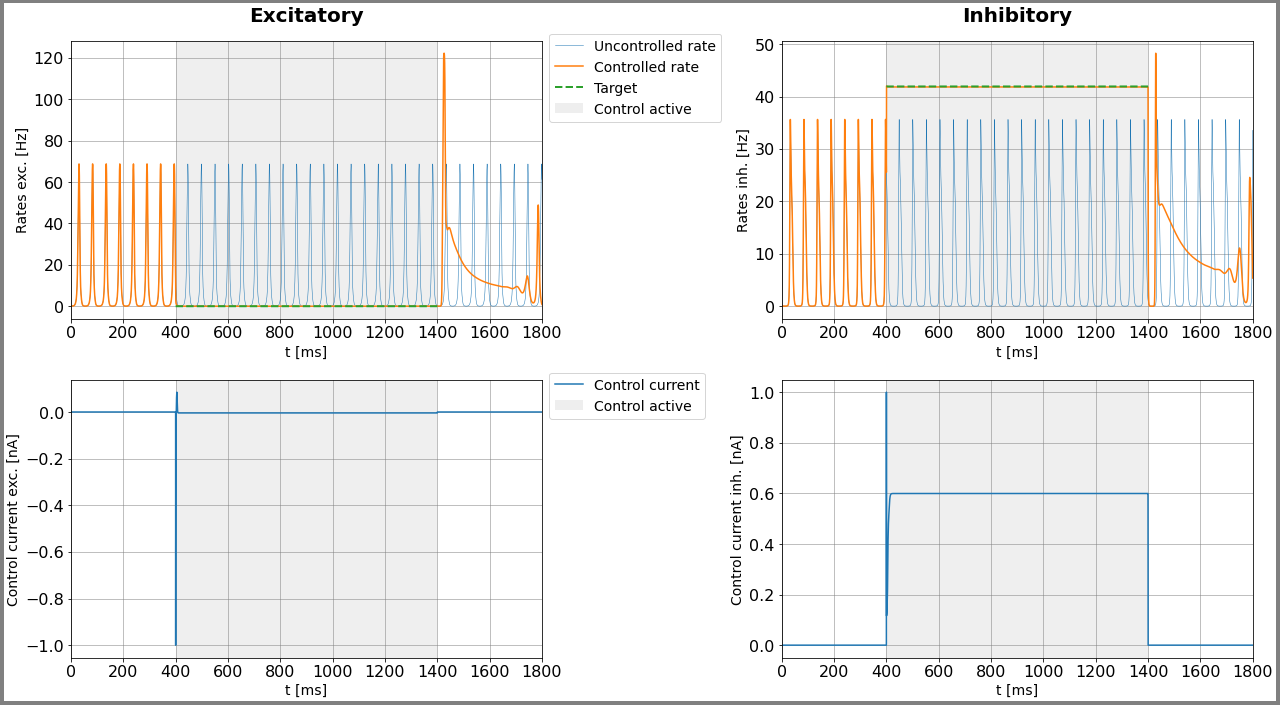

In [12]:
plotFunc.plot_control(aln, bestControlCa2, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

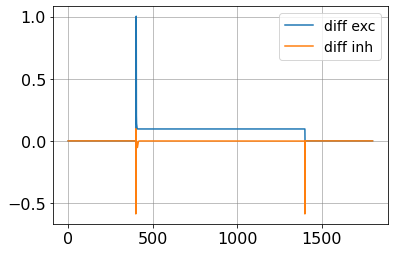

In [13]:
diff = 0.2*(bestControlCa2 - bestControlCa1)

t = np.arange(0, (dur+dur_pre+dur_post+0.1), 0.1)
plt.plot(t, diff[0,0,:], label = "diff exc")
plt.plot(t, diff[0,1,:], label = "diff inh")
plt.legend()
plt.show()

In [14]:
# C.b.1) slow osc => low, max current 1nA, precision only
case = "Cb1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

#max_it = 10

set_params_slow()
setinit(slow_osc_init)

control0 = aln.getZeroControl()
control0[:,0,:] = -2.
control0[:,1,:] = 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlCa1[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCb1, bestStateCb1, costCb1, runtimeCb1, gradCb1 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultCb1 = {"Opt_control": bestControlCb1,
              "Opt_state": bestStateCb1,
              "costArray": costCb1,
              "runtimeArray": runtimeCb1,    
}

dump_dicts = [opt_params, aln.params, resultCb1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  454.12413139500575
too small start step, increase to  1280.0
too small start step, increase to  163840.0
too small start step, increase to  20971520.0
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  299.2854335454954
too large start step, decrease to  163840.0
RUN  2 , total integrated cost =  249.85578596133237
too small start step, increase to  20971520.0
RUN  3 , total integrated cost =  223.05723521837115
too large start step, decrease to  163840.0
RUN  4 , total integrated cost =  206.18533386673147
RUN  5 , total integrated cost =  194.16491229471106
too large start step, decrease to  1280.0
RUN  6 , total integrated cost =  185.01032189820438
too small start step, increase to  163840.0
RUN  7 , total integrated cost =  177.6582367032147
too large start step, decrease to  1280.0
RUN  8 , total integrated cost =  171.64830192692077
too small start step, incre

RUN  130 , total integrated cost =  134.0371173126122
RUN  131 , total integrated cost =  134.03698276032986
RUN  132 , total integrated cost =  134.0368436889008
RUN  133 , total integrated cost =  134.03670549424012
RUN  134 , total integrated cost =  134.03659915095798
RUN  135 , total integrated cost =  134.0364426286718
RUN  136 , total integrated cost =  134.03634979157704
RUN  137 , total integrated cost =  134.03627787452277
RUN  138 , total integrated cost =  134.03621165966038
RUN  139 , total integrated cost =  134.03614995171807
RUN  140 , total integrated cost =  134.03608902445276
RUN  141 , total integrated cost =  134.03598315608332
RUN  142 , total integrated cost =  134.03589201757228
RUN  143 , total integrated cost =  134.03582845123088
RUN  144 , total integrated cost =  134.03577358077106
RUN  145 , total integrated cost =  134.03571998769343
RUN  146 , total integrated cost =  134.03567004077405
RUN  147 , total integrated cost =  134.0355561812995
RUN  148 , tot

RUN  259 , total integrated cost =  134.0331238815226
too large start step, decrease to  1280.0
RUN  260 , total integrated cost =  134.03311686576149
too small start step, increase to  163840.0
RUN  261 , total integrated cost =  134.0331102303435
too large start step, decrease to  1280.0
RUN  262 , total integrated cost =  134.03310386648926
RUN  263 , total integrated cost =  134.03309697578635
RUN  264 , total integrated cost =  134.03309056184722
RUN  265 , total integrated cost =  134.03308426729038
RUN  266 , total integrated cost =  134.033078010041
RUN  267 , total integrated cost =  134.0330719664483
RUN  268 , total integrated cost =  134.03306586564025
too small start step, increase to  163840.0
RUN  269 , total integrated cost =  134.03306000897845
too large start step, decrease to  1280.0
RUN  270 , total integrated cost =  134.03305407204192
too small start step, increase to  163840.0
RUN  271 , total integrated cost =  134.03304395649266
too large start step, decrease t

too large start step, decrease to  1280.0
RUN  368 , total integrated cost =  134.03264363208268
too small start step, increase to  163840.0
RUN  369 , total integrated cost =  134.03264158872142
too large start step, decrease to  1280.0
RUN  370 , total integrated cost =  134.0326395183274
RUN  371 , total integrated cost =  134.03263751992242
RUN  372 , total integrated cost =  134.03263562299733
RUN  373 , total integrated cost =  134.03263357673447
RUN  374 , total integrated cost =  134.03263165092042
RUN  375 , total integrated cost =  134.03262976707381
RUN  376 , total integrated cost =  134.0326278768731
too small start step, increase to  163840.0
RUN  377 , total integrated cost =  134.03262605504963
too large start step, decrease to  1280.0
RUN  378 , total integrated cost =  134.03262427972916
too small start step, increase to  163840.0
RUN  379 , total integrated cost =  134.03262216312453
too large start step, decrease to  1280.0
RUN  380 , total integrated cost =  134.03

RUN  473 , total integrated cost =  134.0324907959547
too large start step, decrease to  1280.0
RUN  474 , total integrated cost =  134.03248998506666
RUN  475 , total integrated cost =  134.03248922006753
RUN  476 , total integrated cost =  134.03248850723546
too small start step, increase to  163840.0
RUN  477 , total integrated cost =  134.0324876028889
too large start step, decrease to  1280.0
RUN  478 , total integrated cost =  134.03248680604662
RUN  479 , total integrated cost =  134.03248610169902
RUN  480 , total integrated cost =  134.03248530002423
RUN  481 , total integrated cost =  134.03248448131976
RUN  482 , total integrated cost =  134.03248378294975
RUN  483 , total integrated cost =  134.03248307932816
RUN  484 , total integrated cost =  134.03248239079286
too small start step, increase to  163840.0
RUN  485 , total integrated cost =  134.03248172551196
too large start step, decrease to  1280.0
RUN  486 , total integrated cost =  134.0324810756949
too small start ste

RUN  604 , total integrated cost =  134.03242575489082
RUN  605 , total integrated cost =  134.03242550080049
RUN  606 , total integrated cost =  134.03242527013055
RUN  607 , total integrated cost =  134.03242503989046
RUN  608 , total integrated cost =  134.03242481564732
RUN  609 , total integrated cost =  134.0324245916703
RUN  610 , total integrated cost =  134.03242437286337
RUN  611 , total integrated cost =  134.03242406204515
RUN  612 , total integrated cost =  134.03242380748907
RUN  613 , total integrated cost =  134.0324235787391
RUN  614 , total integrated cost =  134.0324233613931
RUN  615 , total integrated cost =  134.03242315013188
RUN  616 , total integrated cost =  134.03242293795594
RUN  617 , total integrated cost =  134.03242273211808
RUN  618 , total integrated cost =  134.0324225249087
RUN  619 , total integrated cost =  134.03242228402445
RUN  620 , total integrated cost =  134.03242205714128
RUN  621 , total integrated cost =  134.03242177767157
RUN  622 , tot

RUN  751 , total integrated cost =  134.0324037200197
RUN  752 , total integrated cost =  134.03240365381987
RUN  753 , total integrated cost =  134.03240358568445
RUN  754 , total integrated cost =  134.03240351956174
RUN  755 , total integrated cost =  134.03240345414818
RUN  756 , total integrated cost =  134.0324033884406
RUN  757 , total integrated cost =  134.0324033252212
RUN  758 , total integrated cost =  134.03240325991771
RUN  759 , total integrated cost =  134.03240319385043
RUN  760 , total integrated cost =  134.03240312442503
RUN  761 , total integrated cost =  134.03240305415042
RUN  762 , total integrated cost =  134.03240297265634
RUN  763 , total integrated cost =  134.032402893283
RUN  764 , total integrated cost =  134.0324028250712
RUN  765 , total integrated cost =  134.03240275991848
RUN  766 , total integrated cost =  134.03240269908335
RUN  767 , total integrated cost =  134.03240263979035
RUN  768 , total integrated cost =  134.03240258426905
RUN  769 , total

RUN  877 , total integrated cost =  134.03239808775064
RUN  878 , total integrated cost =  134.03239806575604
too small start step, increase to  20971520.0
RUN  879 , total integrated cost =  134.0323980439613
too large start step, decrease to  163840.0
RUN  880 , total integrated cost =  134.03239802249
too small start step, increase to  20971520.0
RUN  881 , total integrated cost =  134.03239800098734
too large start step, decrease to  163840.0
RUN  882 , total integrated cost =  134.03239798005947
too small start step, increase to  20971520.0
RUN  883 , total integrated cost =  134.03239795881103
too large start step, decrease to  163840.0
RUN  884 , total integrated cost =  134.03239793839202
RUN  885 , total integrated cost =  134.03239791073867
RUN  886 , total integrated cost =  134.0323978888252
RUN  887 , total integrated cost =  134.0323978679545
RUN  888 , total integrated cost =  134.0323978466875
too small start step, increase to  20971520.0
RUN  889 , total integrated cos

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  134.03239620817968
Improved over  1000  iterations by  70.48551553592827  percent.
Problem in initial value trasfer:  Vmean_exc -64.07122889987009 -64.06608384386291
Problem in initial value trasfer:  Vmean_exc -80.81132598823693 -80.81132528486627


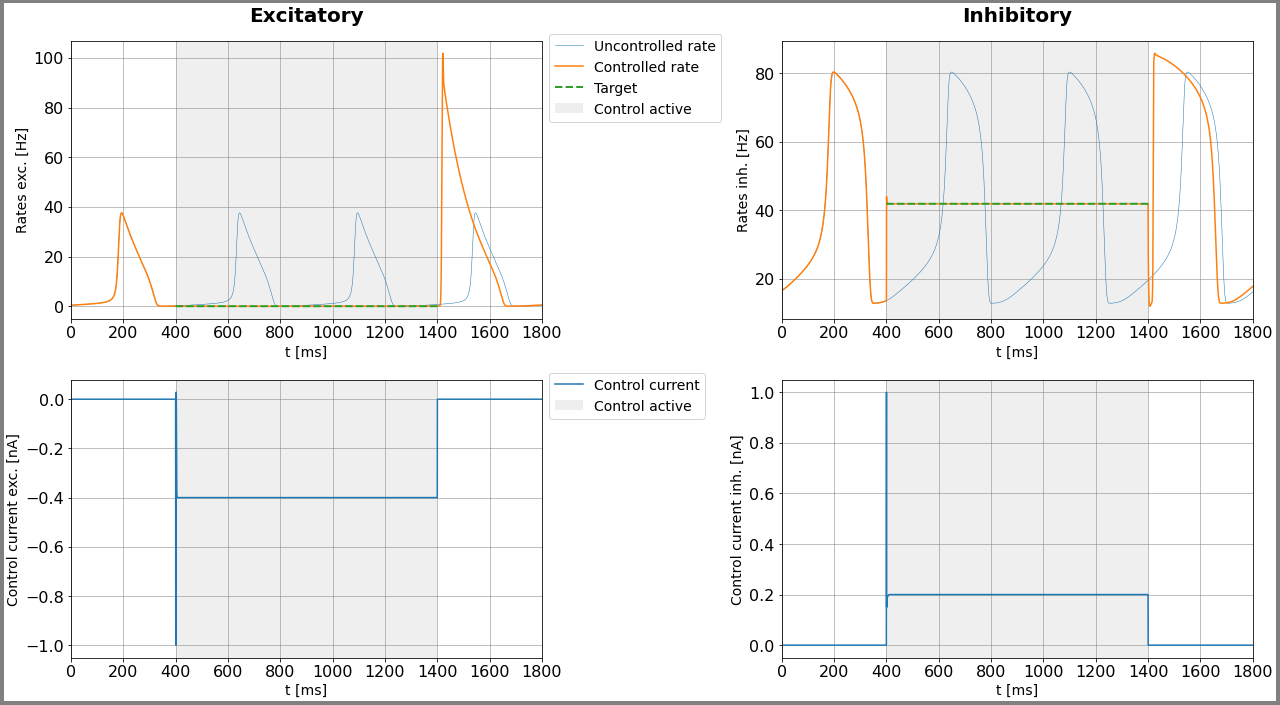

In [15]:
plotFunc.plot_control(aln, bestControlCb1, dur, dur_pre, dur_post, slow_osc_init, target,
                      path, filename_ = case )

In [16]:
# C.b.2) slow osc => low, max current 1nA, precision + energy + sparsity
case = "Cb2"
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

#max_it = 10

setinit(slow_osc_init)
control0 = aln.getZeroControl()
control0[:,0,:] = -2.
control0[:,1,:] = 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlCa2[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlCb2, bestStateCb2, costCb2, runtimeCb2, gradCb2 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultCb2 = {"Opt_control": bestControlCb2,
              "Opt_state": bestStateCb2,
              "costArray": costCb2,
              "runtimeArray": runtimeCb2,    
}

dump_dicts = [opt_params, aln.params, resultCb2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  3049.2472044979754
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  858.6272236300856
RUN  2 , total integrated cost =  790.8854450301029
RUN  3 , total integrated cost =  757.9714050663359
RUN  4 , total integrated cost =  739.0146887144664
RUN  5 , total integrated cost =  724.2951946506013
RUN  6 , total integrated cost =  713.8072824056619
RUN  7 , total integrated cost =  706.4274022545384
RUN  8 , total integrated cost =  700.6287709387757
RUN  9 , total integrated cost =  695.598199835359
RUN  10 , total integrated cost =  691.1102830256862
RUN  11 , total integrated cost =  687.0175283236438
RUN  12 , total integrated cost =  683.4053546779894
RUN  13 , total integrated cost =  679.6951089798572
RUN  14 , total integrated cost =  676.5616177325996
RUN  15 , total integrated cost =  674.0029468906968
too large start step, decrease to  0.078125
RUN  16 , tota

RUN  152 , total integrated cost =  647.0382584764249
RUN  153 , total integrated cost =  646.989262726979
RUN  154 , total integrated cost =  646.9404418057935
RUN  155 , total integrated cost =  646.8920947262054
RUN  156 , total integrated cost =  646.8436786715661
RUN  157 , total integrated cost =  646.7948714467764
RUN  158 , total integrated cost =  646.7465008090197
RUN  159 , total integrated cost =  646.6987445035129
RUN  160 , total integrated cost =  646.6512298384735
RUN  161 , total integrated cost =  646.6036243624948
RUN  162 , total integrated cost =  646.55532164361
RUN  163 , total integrated cost =  646.5063976033772
RUN  164 , total integrated cost =  646.4577048058611
RUN  165 , total integrated cost =  646.4087641116975
RUN  166 , total integrated cost =  646.3607711596325
RUN  167 , total integrated cost =  646.312501776405
RUN  168 , total integrated cost =  646.2635146358118
RUN  169 , total integrated cost =  646.2153821194537
RUN  170 , total integrated cost

RUN  252 , total integrated cost =  642.5538256208349
RUN  253 , total integrated cost =  642.5334321842087
RUN  254 , total integrated cost =  642.5137255148993
RUN  255 , total integrated cost =  642.4939215788654
RUN  256 , total integrated cost =  642.473960239714
RUN  257 , total integrated cost =  642.4545292747356
RUN  258 , total integrated cost =  642.4343471574452
RUN  259 , total integrated cost =  642.4152326920026
RUN  260 , total integrated cost =  642.3962163002959
RUN  261 , total integrated cost =  642.3779141167645
RUN  262 , total integrated cost =  642.3599406648982
RUN  263 , total integrated cost =  642.3418948920958
RUN  264 , total integrated cost =  642.3235216617892
RUN  265 , total integrated cost =  642.3054608261414
RUN  266 , total integrated cost =  642.2881073345126
RUN  267 , total integrated cost =  642.2702084450315
RUN  268 , total integrated cost =  642.2531790061037
RUN  269 , total integrated cost =  642.235805649569
RUN  270 , total integrated co

RUN  405 , total integrated cost =  640.8737806202411
RUN  406 , total integrated cost =  640.8701816676469
too large start step, decrease to  0.0006103515625
RUN  407 , total integrated cost =  640.8663384373381
too small start step, increase to  0.078125
RUN  408 , total integrated cost =  640.861660814093
too large start step, decrease to  0.0006103515625
RUN  409 , total integrated cost =  640.856568866265
too small start step, increase to  0.078125
RUN  410 , total integrated cost =  640.8486498426075
too large start step, decrease to  0.0006103515625
RUN  411 , total integrated cost =  640.8418228437533
too small start step, increase to  0.078125
RUN  412 , total integrated cost =  640.8357358812984
too large start step, decrease to  0.0006103515625
RUN  413 , total integrated cost =  640.8313533991359
too small start step, increase to  0.078125
RUN  414 , total integrated cost =  640.8265158880158
too large start step, decrease to  0.0006103515625
RUN  415 , total integrated cos

too large start step, decrease to  0.0006103515625
RUN  487 , total integrated cost =  640.4750021508777
too small start step, increase to  0.078125
RUN  488 , total integrated cost =  640.4679206455895
too large start step, decrease to  0.0006103515625
RUN  489 , total integrated cost =  640.462269057498
too small start step, increase to  0.078125
RUN  490 , total integrated cost =  640.4576017031184
too large start step, decrease to  0.0006103515625
RUN  491 , total integrated cost =  640.4540811849482
too small start step, increase to  0.078125
RUN  492 , total integrated cost =  640.4490155968502
too large start step, decrease to  0.0006103515625
RUN  493 , total integrated cost =  640.4440974423472
too small start step, increase to  0.078125
RUN  494 , total integrated cost =  640.4400208730231
too large start step, decrease to  0.0006103515625
RUN  495 , total integrated cost =  640.4359391310534
too small start step, increase to  0.078125
RUN  496 , total integrated cost =  640.

...

too small start step, increase to  0.078125
RUN  749 , total integrated cost =  639.8721651798543
too large start step, decrease to  0.0006103515625
RUN  750 , total integrated cost =  639.8702817808751
too small start step, increase to  0.078125
RUN  751 , total integrated cost =  639.8686071711684
too large start step, decrease to  0.0006103515625
RUN  752 , total integrated cost =  639.8666823450685
too small start step, increase to  0.078125
RUN  753 , total integrated cost =  639.8649316994922
too large start step, decrease to  0.0006103515625
RUN  754 , total integrated cost =  639.8630534467476
too small start step, increase to  0.078125
RUN  755 , total integrated cost =  639.8613674530922
too large start step, decrease to  0.0006103515625
RUN  756 , total integrated cost =  639.8594643575028
too small start step, increase to  0.078125
RUN  757 , total integrated cost =  639.8577572728791
too large start step, decrease to  0.0006103515625
RUN  758 , total integrated cost =  639

too large start step, decrease to  0.0006103515625
RUN  832 , total integrated cost =  639.7245787413603
too small start step, increase to  0.078125
RUN  833 , total integrated cost =  639.7228928320042
too large start step, decrease to  0.0006103515625
RUN  834 , total integrated cost =  639.7210595656236
too small start step, increase to  0.078125
RUN  835 , total integrated cost =  639.7194424446992
too large start step, decrease to  0.0006103515625
RUN  836 , total integrated cost =  639.7175611166252
too small start step, increase to  0.078125
RUN  837 , total integrated cost =  639.7158793260589
too large start step, decrease to  0.0006103515625
RUN  838 , total integrated cost =  639.7140385541019
too small start step, increase to  0.078125
RUN  839 , total integrated cost =  639.7124278270852
too large start step, decrease to  0.0006103515625
RUN  840 , total integrated cost =  639.7105437787951
too small start step, increase to  0.078125
RUN  841 , total integrated cost =  639

too small start step, increase to  0.078125
RUN  925 , total integrated cost =  639.5658706435557
too large start step, decrease to  0.0006103515625
RUN  926 , total integrated cost =  639.5640484478356
too small start step, increase to  0.078125
RUN  927 , total integrated cost =  639.5625271966778
too large start step, decrease to  0.0006103515625
RUN  928 , total integrated cost =  639.5607117567757
too small start step, increase to  0.078125
RUN  929 , total integrated cost =  639.5591657540381
too large start step, decrease to  0.0006103515625
RUN  930 , total integrated cost =  639.5573487247749
too small start step, increase to  0.078125
RUN  931 , total integrated cost =  639.5558212308497
too large start step, decrease to  0.0006103515625
RUN  932 , total integrated cost =  639.5540153779554
RUN  933 , total integrated cost =  639.5524631993512
RUN  934 , total integrated cost =  639.5506535635618
RUN  935 , total integrated cost =  639.5490223617295
RUN  936 , total integrate

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


too large start step, decrease to  0.0006103515625
RUN  1000 , total integrated cost =  639.4459532585611
Improved over  1000  iterations by  79.02938297966436  percent.
Problem in initial value trasfer:  Vmean_exc -64.07122889987009 -64.06608384386291
Problem in initial value trasfer:  Vmean_exc -64.69452521535851 -64.70483254907583


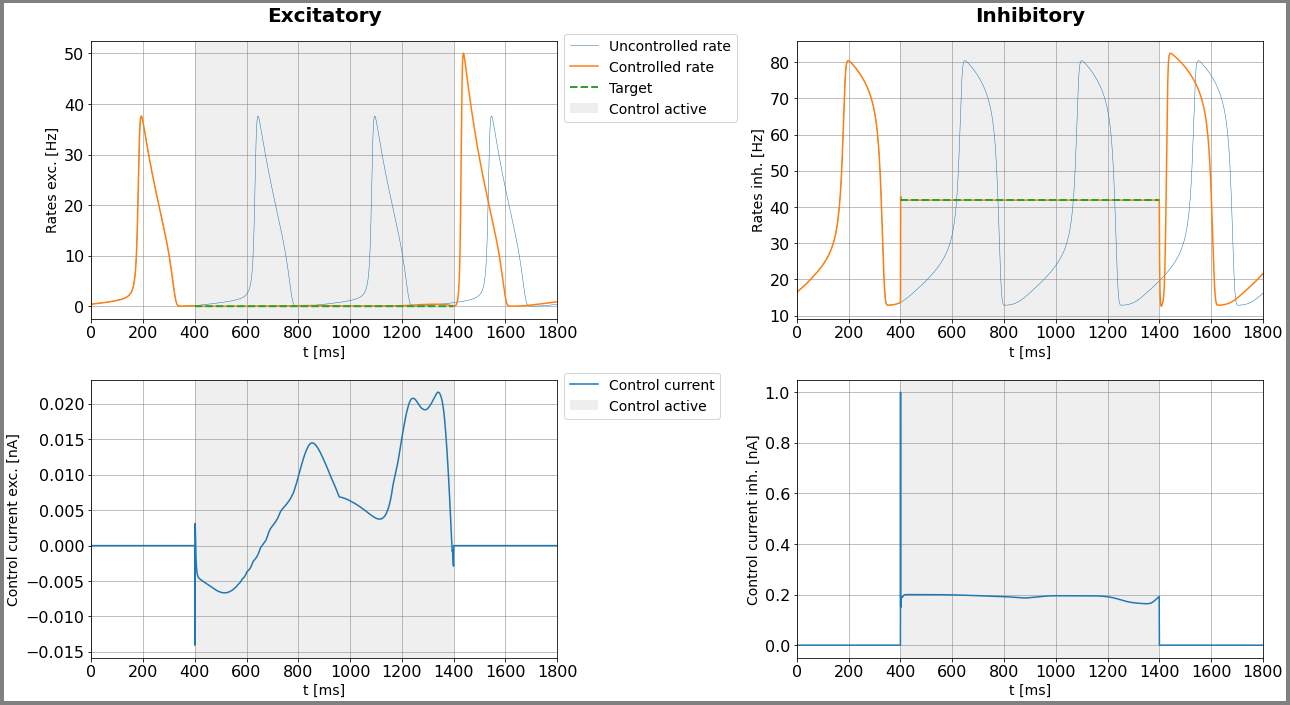

In [17]:
plotFunc.plot_control(aln, bestControlCb2, dur, dur_pre, dur_post, slow_osc_init, target,
                      path, filename_ = case )

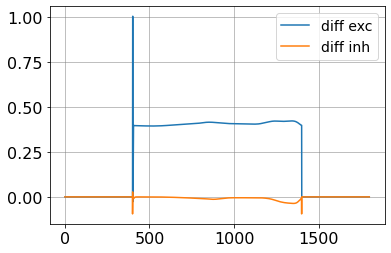

In [18]:
diff = 0.2*(bestControlCb2 - bestControlCb1)

t = np.arange(0, (dur+dur_pre+dur_post+0.1), 0.1)
plt.plot(t, diff[0,0,:], label = "diff exc")
plt.plot(t, diff[0,1,:], label = "diff inh")
plt.legend()
plt.show()